# Анализ данных. Практика
## Базовые инструменты анализа данных в Python

**Содержание:**
1. [Pandas](#pandas) — обработка и анализ данных
2. [SciPy](#scipy) — научные и инженерные расчёты
3. [NumPy](#numpy) — многомерные массивы и матрицы
4. [Matplotlib](#matplotlib) — базовая визуализация
5. [Pandas plot()](#pandas-plot) — встроенные графики Pandas
6. [Seaborn](#seaborn) — статистическая визуализация
7. [Plotly / Cufflinks](#plotly) — интерактивная визуализация
8. [Итого](#итого) — сводная таблица видов анализа


---
<a id="pandas"></a>
# 1. Pandas

**Pandas** — библиотека для обработки и анализа данных в Python.

```python
import pandas as pd
```

### Основные типы данных
| Тип | Описание | Создание |
|-----|----------|----------|
| `Series` | Одномерный массив | `df = pd.Series()` |
| `DataFrame` | Таблица (двумерный массив) | `df = pd.DataFrame()` |

### Ключевые методы DataFrame (для Series — аналогично)
| Метод | Описание |
|-------|----------|
| `pd.DataFrame(data, index=index, …)` | Создание датафрейма |
| `df.shape` | Размер датафрейма |
| `df.info()` | Информация о датафрейме |
| `df.copy()` | Копирование датафрейма |
| `pd.read_csv(filename)` | Создание датафрейма из csv-файла |
| `df.head(n)`, `df.tail(n)` | Первые/последние n строк |
| `df.sort_values([columns])` | Сортировка датафрейма |
| `df.groupby([columns])[column].agg()` | Группировка данных |
| `df.apply(function)` | Применение функции к столбцам |


## 1.1 Создание DataFrame

### Способы создания

- **Из файла:** `pd.read_<формат файла>`. Поддерживаются csv, excel, URL, pickle, json, html, sql, parquet и др.:
  ```python
  df = pd.read_csv(<имя файла>, <параметры>)
  ```
- **Из словаря:** `df = pd.DataFrame(some_dict)` или `pd.DataFrame.from_dict(some_dict)`
- **Из списка:** `df = pd.DataFrame(some_list)`
- **Пустой датафрейм:** `df = pd.DataFrame()`
- **С индексами:** `df = pd.DataFrame(index=some_list)`
- **С колонками:** `df = pd.DataFrame(columns=some_list)`

> Series создаётся идентично DataFrame, но принимает одномерные данные.


In [1]:
import pandas as pd

In [2]:
# Из словаря
pd.DataFrame({'column1': [11, 21, 31], 
              'column2': [12, 22, 32],
              'column3': [13, 23, 33]})

,column1,column2,column3
0,11,12,13
1,21,22,23
2,31,32,33


In [3]:
# Из списка списков с указанием колонок
pd.DataFrame([[11, 12, 13], 
              [21, 22, 23],
              [31, 32, 33]],
            columns=['col1','col2','col3'])

,col1,col2,col3
0,11,12,13
1,21,22,23
2,31,32,33


In [4]:
# Series с именованными индексами
pd.Series(range(5), 
          index=['id1','id2','id3','id4','id5'])

id1    0
id2    1
id3    2
id4    3
id5    4
dtype: int64

In [6]:
import random

# Датафрейм с именованными строками
dict1 = {
    f"column{i}": [random.randint(0,100) for i in range(5)] for i in range(5)
}

df = pd.DataFrame(dict1, index=[f"row{i}" for i in range(5)])
df

,column0,column1,column2,column3,column4
row0,100,18,75,71,81
row1,83,16,47,90,23
row2,74,6,50,70,36
row3,60,29,80,69,13
row4,38,21,41,35,67


## 1.2 Обращение к элементам DataFrame

Обращение к элементам датафрейма возможно:

| Способ | Синтаксис | Описание |
|--------|-----------|----------|
| По целочисленному индексу | `df.iloc[<строка>, <колонка>]` | Позиционный доступ |
| По текстовой метке | `df.loc[<метка строки>, <метка колонки>]` | Доступ по имени |
| По колонке | `df[<метка колонки>]` | Вся колонка |
| По строке | `df.loc[<метка строки>]` | Вся строка |

Поддерживаются **слайсы** (как в списках и кортежах):
```python
df.loc['row2':'row3', 'column1':'column3']  # диапазон строк и колонок
```


In [7]:
df.iloc[1,1]  # по позиции: строка 1, колонка 1

np.int64(16)

In [8]:
df.loc['row1','column1']  # по метке

np.int64(16)

In [9]:
df['column2']  # вся колонка

row0    75
row1    47
row2    50
row3    80
row4    41
Name: column2, dtype: int64

In [10]:
df.loc['row1']  # вся строка

column0    83
column1    16
column2    47
column3    90
column4    23
Name: row1, dtype: int64

In [11]:
df.loc['row2':'row3', 'column1':'column3']  # слайс строк и колонок

,column1,column2,column3
row2,6,50,70
row3,29,80,69


## 1.3 Фильтрация данных

Для выбора значений, подходящих под условие:

### Способ 1 — через индексы
```python
df[(df['col1'] > 40) & (df['col3'] < 60)]
```
Каждое условие заключается в `()`, между скобками ставится `&` (и) или `|` (или).  
Каждое условие возвращает Series с булевыми значениями.

### Способ 2 — через query
```python
df.query("col1 > 40 and col3 < 60")
```


In [22]:
# Фильтрация через булевы индексы
df[(df['column1']>40) & (df['column3']<60)]

,column0,column1,column2,column3,column4


In [23]:
# Фильтрация через query
df.query("column1 > 40 and column3 < 60")

,column0,column1,column2,column3,column4


In [24]:
# Одно условие возвращает Series булевых значений
df['column3'] < 60

row0    False
row1    False
row2    False
row3    False
row4     True
Name: column3, dtype: bool

In [25]:
df['column1'] > 40

row0    False
row1    False
row2    False
row3    False
row4    False
Name: column1, dtype: bool

In [30]:
#если нужно использовать переменные в методе query - обращение с помощью префикса @
a = 20
df.query("column1 > @a")

,column0,column1,column2,column3,column4
row3,60,29,80,69,13
row4,38,21,41,35,67


## 1.4 Изменение и добавление элементов

Для изменения элемента обратитесь к нему через `loc` или `iloc`:
```python
df.loc['row1', 'column1'] = 10
df.iloc[1, 2] = 20
```

Новую колонку или строку можно добавить с нуля или на основе других данных:
```python
df['new_col'] = df['col4'] * 2      # новая колонка на основе другой
df['new_col'] = range(df.shape[0])  # новая колонка из последовательности
df.loc['new_row'] = df.loc['row4'] + 10  # новая строка
```


In [31]:
# Создаём датафрейм для демонстрации
dict1 = {
    f"column{i}": [j+i*10 for j in range(5)] for i in range(5)
}

df = pd.DataFrame(dict1, index=[f"row{i}" for i in range(5)])
df

,column0,column1,column2,column3,column4
row0,0,10,20,30,40
row1,1,11,21,31,41
row2,2,12,22,32,42
row3,3,13,23,33,43
row4,4,14,24,34,44


In [32]:
# Изменение существующих значений
df.loc['row1', 'column1'] = 10
df.iloc[1, 2] = 20
df.loc['row1', 'column1'], df.iloc[1, 2]

(np.int64(10), np.int64(20))

In [33]:
# Добавление новых колонок
df['column5'] = df['column4'] * 2
df['column6'] = range(df.shape[0])
df['column7'] = 99
df

,column0,column1,column2,column3,column4,column5,column6,column7
row0,0,10,20,30,40,80,0,99
row1,1,10,20,31,41,82,1,99
row2,2,12,22,32,42,84,2,99
row3,3,13,23,33,43,86,3,99
row4,4,14,24,34,44,88,4,99


In [35]:
# Добавление новых строк
df.loc['row5'] = df.loc['row4'] + 10
df.loc['row6'] = range(df.shape[1])
df.loc['row7'] = 99
df

,column0,column1,column2,column3,column4,column5,column6,column7
row0,0,10,20,30,40,80,0,99
row1,1,10,20,31,41,82,1,99
row2,2,12,22,32,42,84,2,99
row3,3,13,23,33,43,86,3,99
row4,4,14,24,34,44,88,4,99
row5,14,24,34,44,54,98,14,109
row6,0,1,2,3,4,5,6,7
row7,99,99,99,99,99,99,99,99


## 1.5 Удаление элементов. Параметр `axis`

Метод `drop()` удаляет строки или колонки. 
*Важно*: методы, изменяющие `DataFrame` по умолчанию не меняют текущий `DataFrame`, а возвращают модифицированный `DataFrame`
изменение этого поведения возможно за счет параметра `inplace`
Параметр `axis=1` — операция над колонками, `axis=0` — над строками.

```python
df.drop(['col1', 'col2'], axis=1)   # удалить колонки
df.drop(['row2', 'row3'])           # удалить строки (axis=0 по умолчанию)
```

Для удаления пропущенных значений (`NaN`) используйте `dropna()`:

| Параметр | Описание |
|----------|----------|
| `axis=0` | удалять строки (по умолчанию) |
| `axis=1` | удалять колонки |
| `how='all'` | удалять, если **все** значения NaN |
| `how='any'` | удалять, если **хотя бы одно** NaN (поведение по умолчанию) |
| `subset=[…]` | искать NaN только в конкретных колонках |


In [36]:
import numpy as np

# Удаление колонок и строк
df.drop(['column1', 'column2'], axis=1)

,column0,column3,column4,column5,column6,column7
row0,0,30,40,80,0,99
row1,1,31,41,82,1,99
row2,2,32,42,84,2,99
row3,3,33,43,86,3,99
row4,4,34,44,88,4,99
row5,14,44,54,98,14,109
row6,0,3,4,5,6,7
row7,99,99,99,99,99,99


In [37]:
df.drop(['row2', 'row3'])

,column0,column1,column2,column3,column4,column5,column6,column7
row0,0,10,20,30,40,80,0,99
row1,1,10,20,31,41,82,1,99
row4,4,14,24,34,44,88,4,99
row5,14,24,34,44,54,98,14,109
row6,0,1,2,3,4,5,6,7
row7,99,99,99,99,99,99,99,99


In [38]:
# Добавим NaN в несколько случайных ячеек
for _ in range(5):
    row = random.choice(df.index) 
    column = random.choice(df.columns)
    df.loc[row, column] = np.nan
df

,column0,column1,column2,column3,column4,column5,column6,column7
row0,0.0,NaN,20,30,NaN,80,0,99
row1,1.0,10.0,20,31,41.0,82,1,99
row2,2.0,12.0,22,32,42.0,84,2,99
row3,3.0,13.0,23,33,43.0,86,3,99
row4,NaN,14.0,24,34,44.0,88,4,99
row5,14.0,24.0,34,44,54.0,98,14,109
row6,0.0,NaN,2,3,4.0,5,6,7
row7,99.0,99.0,99,99,99.0,99,99,99


In [39]:
# Удалить строки с любым NaN
df.dropna()

,column0,column1,column2,column3,column4,column5,column6,column7
row1,1.0,10.0,20,31,41.0,82,1,99
row2,2.0,12.0,22,32,42.0,84,2,99
row3,3.0,13.0,23,33,43.0,86,3,99
row5,14.0,24.0,34,44,54.0,98,14,109
row7,99.0,99.0,99,99,99.0,99,99,99


In [40]:
df.dropna(how="all")

,column0,column1,column2,column3,column4,column5,column6,column7
row0,0.0,NaN,20,30,NaN,80,0,99
row1,1.0,10.0,20,31,41.0,82,1,99
row2,2.0,12.0,22,32,42.0,84,2,99
row3,3.0,13.0,23,33,43.0,86,3,99
row4,NaN,14.0,24,34,44.0,88,4,99
row5,14.0,24.0,34,44,54.0,98,14,109
row6,0.0,NaN,2,3,4.0,5,6,7
row7,99.0,99.0,99,99,99.0,99,99,99


In [41]:
df  # исходный датафрейм не изменён

,column0,column1,column2,column3,column4,column5,column6,column7
row0,0.0,NaN,20,30,NaN,80,0,99
row1,1.0,10.0,20,31,41.0,82,1,99
row2,2.0,12.0,22,32,42.0,84,2,99
row3,3.0,13.0,23,33,43.0,86,3,99
row4,NaN,14.0,24,34,44.0,88,4,99
row5,14.0,24.0,34,44,54.0,98,14,109
row6,0.0,NaN,2,3,4.0,5,6,7
row7,99.0,99.0,99,99,99.0,99,99,99


## 1.6 Функция `apply()`

`df.apply()` применяет произвольную функцию к отдельным строкам (`axis=0`) или колонкам (`axis=1`).  
Аргументы передаются через параметр `args=`.

```python
df.apply(function, axis=0, args=(arg1, arg2))
```

Для применения функции к каждому элементу всего датафрейма можно использовать `df.applymap()`.


In [42]:
# Лямбда-функция к нескольким колонкам
df[['column1','column2']].apply(lambda x: x%2)

,column1,column2
row0,NaN,0
row1,0.0,0
row2,0.0,0
row3,1.0,1
row4,0.0,0
row5,0.0,0
row6,NaN,0
row7,1.0,1


In [43]:
# Своя функция с дополнительным аргументом
def some_function(element_df, a):
    return element_df - a

df.apply(some_function, args=(10,))

,column0,column1,column2,column3,column4,column5,column6,column7
row0,-10.0,NaN,10,20,NaN,70,-10,89
row1,-9.0,0.0,10,21,31.0,72,-9,89
row2,-8.0,2.0,12,22,32.0,74,-8,89
row3,-7.0,3.0,13,23,33.0,76,-7,89
row4,NaN,4.0,14,24,34.0,78,-6,89
row5,4.0,14.0,24,34,44.0,88,4,99
row6,-10.0,NaN,-8,-7,-6.0,-5,-4,-3
row7,89.0,89.0,89,89,89.0,89,89,89


## 1.7 Сортировка данных

| Метод | Описание |
|-------|----------|
| `df.sort_values(<колонка>)` | Сортировка по значениям колонки |
| `df.sort_index()` | Сортировка по индексу |

Параметр `ascending=False` — сортировка по убыванию.


In [44]:
df.sort_values('column6', ascending=False)

,column0,column1,column2,column3,column4,column5,column6,column7
row7,99.0,99.0,99,99,99.0,99,99,99
row5,14.0,24.0,34,44,54.0,98,14,109
row6,0.0,NaN,2,3,4.0,5,6,7
row4,NaN,14.0,24,34,44.0,88,4,99
row3,3.0,13.0,23,33,43.0,86,3,99
row2,2.0,12.0,22,32,42.0,84,2,99
row1,1.0,10.0,20,31,41.0,82,1,99
row0,0.0,NaN,20,30,NaN,80,0,99


In [45]:
df.sort_index(ascending=False)

,column0,column1,column2,column3,column4,column5,column6,column7
row7,99.0,99.0,99,99,99.0,99,99,99
row6,0.0,NaN,2,3,4.0,5,6,7
row5,14.0,24.0,34,44,54.0,98,14,109
row4,NaN,14.0,24,34,44.0,88,4,99
row3,3.0,13.0,23,33,43.0,86,3,99
row2,2.0,12.0,22,32,42.0,84,2,99
row1,1.0,10.0,20,31,41.0,82,1,99
row0,0.0,NaN,20,30,NaN,80,0,99


## 1.8 Объединение датафреймов

### pd.concat()
Объединяет датафреймы (или Series) вдоль заданной оси:
```python
pd.concat([df1, df2, …], axis=0)  # вертикально (по умолчанию)
pd.concat([df1, df2, …], axis=1)  # горизонтально
```

### df.merge()
Объединение по заданным условиям (аналог SQL JOIN):
```python
df1.merge(df2, left_on=…, right_on=…, how='inner')
```
Параметр `how` принимает: `'inner'`, `'outer'`, `'left'`, `'right'`.


In [46]:
# Создаём два датафрейма для демонстрации
dict1 = {f"column{i}": [f"A{j+i*10}" for j in range(3)] for i in range(3)}
df_A = pd.DataFrame(dict1, index=[f"row{i}" for i in range(3)])
df_A

,column0,column1,column2
row0,A0,A10,A20
row1,A1,A11,A21
row2,A2,A12,A22


In [47]:
dict1 = {f"column{i}": [f"B{j+i*10}" for j in range(4)] for i in range(4)}
df_B = pd.DataFrame(dict1, index=[f"row{i}" for i in range(4)])
df_B

,column0,column1,column2,column3
row0,B0,B10,B20,B30
row1,B1,B11,B21,B31
row2,B2,B12,B22,B32
row3,B3,B13,B23,B33


In [48]:
pd.concat([df_A, df_B])  # вертикальное объединение

,column0,column1,column2,column3
row0,A0,A10,A20,NaN
row1,A1,A11,A21,NaN
row2,A2,A12,A22,NaN
row0,B0,B10,B20,B30
row1,B1,B11,B21,B31
row2,B2,B12,B22,B32
row3,B3,B13,B23,B33


In [51]:
pd.concat([df_A, df_B], axis=1) # горизонтальное объединение

,column0,column1,column2,column0,column1,column2,column3
row0,A0,A10,A20,B0,B10,B20,B30
row1,A1,A11,A21,B1,B11,B21,B31
row2,A2,A12,A22,B2,B12,B22,B32
row3,NaN,NaN,NaN,B3,B13,B23,B33


In [52]:
df_A.merge(df_B, left_index=True, right_index=True)  # merge по индексам

,column0_x,column1_x,column2_x,column0_y,column1_y,column2_y,column3
row0,A0,A10,A20,B0,B10,B20,B30
row1,A1,A11,A21,B1,B11,B21,B31
row2,A2,A12,A22,B2,B12,B22,B32


## 1.9 Статистика DataFrame

Pandas отлично подходит для описательной аналитики.

| Метод | Описание |
|-------|----------|
| `df.describe()` | Сводная статистика по числовым колонкам |
| `df['col'].mean()` | Среднее значение |
| `df['col'].min()` / `.max()` | Минимум / максимум |
| `df['col'].unique()` | Уникальные значения |
| `df['col'].nunique()` | Количество уникальных значений |
| `df['col'].value_counts()` | Количество каждого значения |

Для примера используем датасет о пассажирах Титаника.


In [54]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('titanic')

In [55]:
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [56]:
df.describe()  # сводная статистика по всем числовым колонкам

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [57]:
df['age'].mean(), df['age'].min(), df['age'].max()

(np.float64(29.69911764705882), np.float64(0.42), np.float64(80.0))

In [58]:
df['pclass'].unique()  # уникальные значения

array([3, 1, 2])

In [59]:
df['pclass'].nunique()  # количество уникальных значений

3

In [60]:
df['pclass'].value_counts()  # количество каждого значения

pclass
3    491
1    216
2    184
Name: count, dtype: int64

## 1.10 Группировка данных

```python
df.groupby([<колонки>])[<колонки для подсчёта>].<агрегирующая функция>()
```

**Стандартные агрегирующие функции:** `'sum'`, `'mean'`, `'median'`, `'min'`, `'max'`, `'std'`, `'var'`, `'mad'`, `'prod'`.

Можно:
- применять **разные** функции к **разным** колонкам через `agg()`
- писать **собственные** агрегирующие функции


In [61]:
df.groupby('pclass')[['fare', 'age']].mean()

,fare,age
pclass,,
1,84.154687,38.233441
2,20.662183,29.877630
3,13.675550,25.140620


In [62]:
(df
 .groupby(['pclass', 'who'])[['fare', 'age']]
 .agg(['min', 'mean', 'max'])
 .round(2)
)

fare                    age             
                min    mean     max    min   mean   max
pclass who                                             
1      child  81.86  139.38  211.34   0.92   7.82  15.0
       man     0.00   65.95  512.33  17.00  42.38  80.0
       woman  25.93  104.32  512.33  16.00  35.50  63.0
2      child  14.50   28.32   41.58   0.67   4.54  14.0
       man     0.00   19.05   73.50  16.00  33.59  70.0
       woman  10.50   20.87   65.00  17.00  32.18  57.0
3      child   7.22   23.22   46.90   0.42   6.82  15.0
       man     0.00   11.34   69.55  16.00  29.00  74.0
       woman   6.75   15.35   69.55  16.00  27.85  63.0

## 1.11 Операции со строками

В Pandas есть специальный форматтер `.str` для удобной работы со строками.  
При его использовании доступны все основные строковые функции:

| Метод | Описание |
|-------|----------|
| `.str.contains(pat)` | Содержит ли значение подстроку |
| `.str.upper()` / `.str.lower()` | Преобразование регистра |
| `.str.count(pat)` | Подсчёт вхождений символа / шаблона |
| `.str.replace(old, new)` | Замена подстроки |
| `.str.strip()` | Удаление пробелов по краям |

Строки можно комбинировать через оператор `+`.


In [63]:
df1 = df[['sex', 'class', 'who', 'embark_town', 'pclass']].copy()
df1

,sex,class,who,embark_town,pclass
0,male,Third,man,Southampton,3
1,female,First,woman,Cherbourg,1
2,female,Third,woman,Southampton,3
3,female,First,woman,Southampton,1
4,male,Third,man,Southampton,3
...,...,...,...,...,...
886,male,Second,man,Southampton,2
887,female,First,woman,Southampton,1
888,female,Third,woman,Southampton,3
889,male,First,man,Cherbourg,1


In [64]:
df1[df1['sex'].str.contains('fem')]  # фильтрация: содержит 'fem'

,sex,class,who,embark_town,pclass
1,female,First,woman,Cherbourg,1
2,female,Third,woman,Southampton,3
3,female,First,woman,Southampton,1
8,female,Third,woman,Southampton,3
9,female,Second,child,Cherbourg,2
...,...,...,...,...,...
880,female,Second,woman,Southampton,2
882,female,Third,woman,Southampton,3
885,female,Third,woman,Queenstown,3
887,female,First,woman,Southampton,1


In [65]:
df1['sex'].str.upper()  # перевод в верхний регистр

0        MALE
1      FEMALE
2      FEMALE
3      FEMALE
4        MALE
        ...  
886      MALE
887    FEMALE
888    FEMALE
889      MALE
890      MALE
Name: sex, Length: 891, dtype: str

In [66]:
df1['sex'].str.count('e')  # подсчёт символа 'e'

0      1
1      2
2      2
3      2
4      1
      ..
886    1
887    2
888    2
889    1
890    1
Name: sex, Length: 891, dtype: int64

In [67]:
# Создание новой колонки через преобразование строк
df1['new_feature'] = df['sex'].str.replace('e','*') + "_" + df['class'].str.lower()
df1

,sex,class,who,embark_town,pclass,new_feature
0,male,Third,man,Southampton,3,mal*_third
1,female,First,woman,Cherbourg,1,f*mal*_first
2,female,Third,woman,Southampton,3,f*mal*_third
3,female,First,woman,Southampton,1,f*mal*_first
4,male,Third,man,Southampton,3,mal*_third
...,...,...,...,...,...,...
886,male,Second,man,Southampton,2,mal*_second
887,female,First,woman,Southampton,1,f*mal*_first
888,female,Third,woman,Southampton,3,f*mal*_third
889,male,First,man,Cherbourg,1,mal*_first


## 1.12 Сохранение DataFrame

```python
df.to_<формат>(<имя файла>, <опции>)
```

Поддерживаются все форматы загрузки: `csv`, `excel`, `json`, `parquet`, `pickle` и т.п.

```python
df.to_csv('output.csv', index=False)         # без столбца индексов
df.to_excel('output.xlsx', index=False)
df.to_json('output.json', orient='records')
df.to_parquet('output.parquet')
```


---
<a id="numpy"></a>
# 3. NumPy

**NumPy** — библиотека для работы с многомерными массивами и матрицами.

```python
import numpy as np
```

**Основной тип данных:** `numpy.ndarray`

### Атрибуты массива

| Атрибут | Описание |
|---------|----------|
| `arr.ndim` | Число измерений |
| `arr.shape` | Размеры по каждому измерению |
| `arr.size` | Общее количество элементов |

### Создание массивов

| Функция | Описание |
|---------|----------|
| `np.array([…])` | Из списка |
| `np.zeros((n, m))` | Массив из нулей |
| `np.ones((n, m))` | Массив из единиц |
| `np.eye(n)` | Единичная матрица |
| `np.arange(start, stop)` | Последовательность (как `range`) |
| `np.linspace(start, stop, n)` | Линейно распределённые значения |
| `np.random.random(n)` | Случайные числа от 0 до 1 |
| `np.empty(shape)` | Пустой массив (остатки памяти) |


## 3.1 Создание массивов

In [71]:
import numpy as np

a = np.array([[1,2], [3,4]])
print(type(a))
print(a)
print('ndim: \t', a.ndim)
print('shape: \t', a.shape)
print('size: \t', a.size)

<class 'numpy.ndarray'>
[[1 2]
 [3 4]]
ndim: 	 2
shape: 	 (2, 2)
size: 	 4


In [72]:
np.zeros((5, 4))  # матрица из нулей

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [73]:
np.ones((5, 4))   # матрица из единиц

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [74]:
np.eye(5)         # единичная матрица

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

In [75]:
np.ones((2,2,2))  # трёхмерный массив

array([[[1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.]]])

## 3.2 Работа с массивами: arange, reshape, flat, слайсы

In [76]:
arr = np.arange(1, 10)  # последовательность от 1 до 9
arr

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [77]:
arr = arr.reshape(3, 3)  # изменение размерности
arr

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [78]:
print("1 элемент:", arr[1,2])
print("Слайс:\n", arr[:2, :2])
print("Другой слайс:\n", arr[:2, :])

1 элемент: 6
Слайс:
 [[1 2]
 [4 5]]
Другой слайс:
 [[1 2 3]
 [4 5 6]]


In [79]:
np.random.random(4)   # случайные числа

array([0.93425011, 0.12532958, 0.66998735, 0.58154124])

In [80]:
np.array(arr.flat)    # приведение к плоскому виду (1D)

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

## 3.3 Операции над массивами

In [81]:
arr1 = np.arange(1,10).reshape(3,3)
arr2 = np.arange(0,12).reshape(3,4)
print("arr1:\n", arr1)
print("arr2:\n", arr2)

arr1:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
arr2:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [82]:
arr1 + 10   # сложение со скаляром

array([[11, 12, 13],
       [14, 15, 16],
       [17, 18, 19]])

In [83]:
arr1 - 10   # вычитание

array([[-9, -8, -7],
       [-6, -5, -4],
       [-3, -2, -1]])

In [84]:
arr1 + arr2[:,:3]  # сложение массивов одинаковой формы

array([[ 1,  3,  5],
       [ 8, 10, 12],
       [15, 17, 19]])

In [85]:
arr1 / 10   # деление

array([[0.1, 0.2, 0.3],
       [0.4, 0.5, 0.6],
       [0.7, 0.8, 0.9]])

In [86]:
arr2 * 2    # умножение

array([[ 0,  2,  4,  6],
       [ 8, 10, 12, 14],
       [16, 18, 20, 22]])

In [87]:
arr1.dot(arr2)  # произведение матриц

array([[ 32,  38,  44,  50],
       [ 68,  83,  98, 113],
       [104, 128, 152, 176]])

In [88]:
np.cos(arr1)    # тригонометрические и другие поэлементные функции

array([[ 0.54030231, -0.41614684, -0.9899925 ],
       [-0.65364362,  0.28366219,  0.96017029],
       [ 0.75390225, -0.14550003, -0.91113026]])

## 3.4 Статистики

Операции могут производиться над всем массивом или отдельно по его осям (`axis=0` — по строкам, `axis=1` — по столбцам).

| Функция | Описание |
|---------|----------|
| `np.max(arr)` / `np.min(arr)` | Максимум / минимум |
| `np.mean(arr)` | Среднее значение |
| `np.median(arr)` | Медиана |
| `np.var(arr)` | Дисперсия |
| `np.std(arr)` | Стандартное отклонение |
| `np.sum(arr)` | Сумма всех элементов |


In [89]:
arr2

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [90]:
np.sum(arr2)           # сумма всех элементов

np.int64(66)

In [91]:
np.sum(arr2, axis=0)   # суммы по столбцам

array([12, 15, 18, 21])

In [92]:
np.sum(arr2, axis=1)   # суммы по строкам

array([ 6, 22, 38])

In [93]:
np.mean(arr2)

np.float64(5.5)

In [94]:
np.var(arr2)    # дисперсия

np.float64(11.916666666666666)

In [95]:
np.std(arr2)    # стандартное отклонение

np.float64(3.452052529534663)

In [96]:
np.median(arr2)

np.float64(5.5)

## 3.5 Объединение и разбиение массивов

### Объединение
| Функция | Описание |
|---------|----------|
| `np.hstack((a, b))` | По горизонтальной оси (добавить столбцы) |
| `np.vstack((a, b))` | По вертикальной оси (добавить строки) |
| `np.column_stack((a, b))` | Одномерные массивы как столбцы |
| `np.row_stack((a, b))` | Одномерные массивы как строки |

### Разбиение
| Функция | Описание |
|---------|----------|
| `np.hsplit(arr, n)` | Разбиение вдоль горизонтальной оси |
| `np.vsplit(arr, n)` | Разбиение вдоль вертикальной оси |


In [97]:
print("arr1:\n", arr1)
print("arr2:\n", arr2)

arr1:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
arr2:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [98]:
np.hstack((arr1, arr2))      # горизонтальное объединение

array([[ 1,  2,  3,  0,  1,  2,  3],
       [ 4,  5,  6,  4,  5,  6,  7],
       [ 7,  8,  9,  8,  9, 10, 11]])

In [99]:
np.vstack((arr1, arr2[:,:3]))  # вертикальное объединение

array([[ 1,  2,  3],
       [ 4,  5,  6],
       [ 7,  8,  9],
       [ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10]])

In [100]:
np.hsplit(arr2, 2)            # разбить arr2 на 2 части по горизонтали

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

---
<a id="matplotlib"></a>
# 4. Matplotlib

**Matplotlib** — пакет для визуализации данных в Python.  
**pyplot** — модуль matplotlib с удобным интерфейсом.

```python
import matplotlib.pyplot as plt
```

### Основные методы

| Метод | Описание |
|-------|----------|
| `plt.plot(x, y)` | Линейный график |
| `plt.scatter(x, y)` | Диаграмма рассеяния |
| `plt.bar(x, y)` | Столбчатая диаграмма |
| `plt.pie(values)` | Круговая диаграмма |
| `plt.boxplot(x)` | Диаграмма распределения |
| `plt.hist(x, bins=n)` | Гистограмма |
| `plt.show()` | Вывод графика |
| `plt.xlabel('…')` / `plt.ylabel('…')` | Подписи осей |
| `plt.title('…')` | Название графика |
| `plt.legend()` | Легенда |
| `plt.grid()` | Сетка |
| `plt.figure(figsize=(w, h))` | Задать размер области |

Диаграммы можно **комбинировать** на одном графике.


In [101]:
import matplotlib.pyplot as plt

In [102]:
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


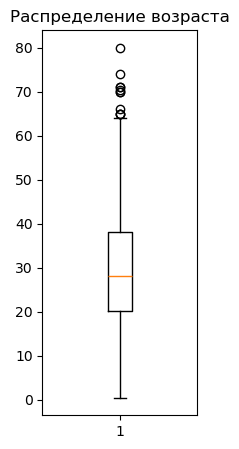

In [103]:
# Диаграмма распределения возраста
x = np.array(df['age'].dropna())
plt.figure(figsize=(2, 5))
plt.boxplot(x)
plt.title('Распределение возраста')
plt.show()

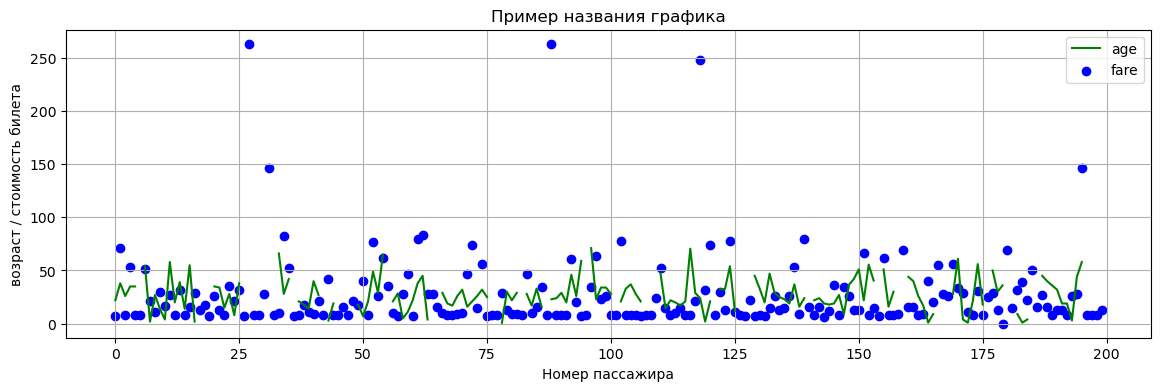

In [104]:
# Линейный и точечный графики на одном поле
size = 200
age = np.array(df['age'][:size])
fare = np.array(df['fare'][:size])

plt.figure(figsize=(14, 4))
plt.title('Пример названия графика')
plt.plot(range(size), age, label='age', color='green')
plt.scatter(range(size), fare, label='fare', color='blue')
plt.xlabel('Номер пассажира')
plt.ylabel('возраст / стоимость билета')
plt.legend()
plt.grid()
plt.show()

## 4.1 Subplots

Для отображения независимых графиков в одном окне:
```python
plt.subplot(<кол-во строк>, <кол-во столбцов>, <ячейка>)
```


In [105]:
# Вспомогательный код для примера
df.groupby('sex')[['sibsp', 'survived']].sum()['sibsp']

sex
female    218
male      248
Name: sibsp, dtype: int64

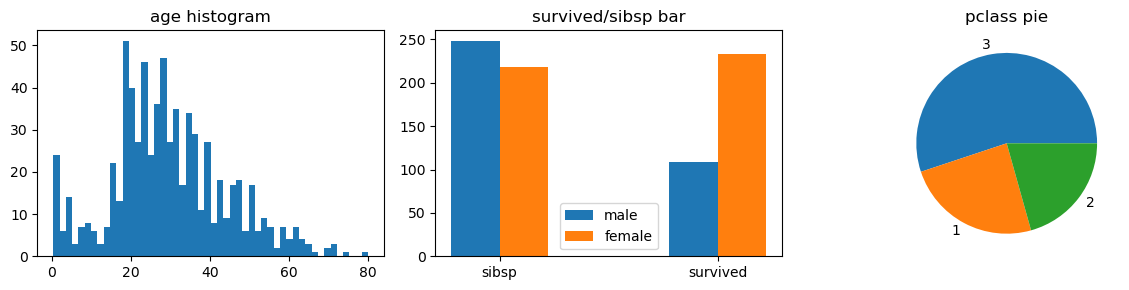

In [106]:
plt.figure(figsize=(12, 3))

plt.subplot(1, 3, 1)
plt.hist(df['age'], bins=50)
plt.title('age histogram')

plt.subplot(1, 3, 2)
sex = df.groupby('sex')[['sibsp', 'survived']].sum()
plt.bar([0.1, 1], sex.loc['male'], 0.2, label='male')
plt.bar([0.3, 1.2], sex.loc['female'], 0.2, label='female')
plt.xticks([0.2, 1.1], ['sibsp','survived'])
plt.title('survived/sibsp bar')
plt.legend()

plt.subplot(1, 3, 3)
pclass = df['pclass'].value_counts()
plt.pie(pclass.values, labels=pclass.index)
plt.title('pclass pie')

plt.tight_layout()
plt.show()

---
<a id="pandas-plot"></a>
# 5. Pandas plot()

Объекты Pandas (`DataFrame`, `Series`) имеют встроенные методы для построения графиков (на базе matplotlib):  
`plot()`, `hist()`, `boxplot()`.

Метод `plot(kind=…)` поддерживает следующие типы:

| `kind` | Тип графика |
|--------|-------------|
| `'line'` | Линейный (по умолчанию) |
| `'bar'` | Вертикальная гистограмма |
| `'barh'` | Горизонтальная гистограмма |
| `'hist'` | Гистограмма частот |
| `'box'` | "Ящик с усами" |
| `'scatter'` | График рассеяния |
| `'pie'` | Круговая диаграмма |
| `'area'` | График с накоплением |
| `'kde'` / `'density'` | Оценка плотности ядра |
| `'hexbin'` | Шестиугольная диаграмма |

Это удобнее исходного синтаксиса matplotlib для быстрого взгляда на данные:  
визуализация настраивается в одну строку.

> 📎 [Руководство по Pandas plot](http://cs.petrsu.ru/~musen/python/prezent_pdf/lecture_7.html)


<Axes: >

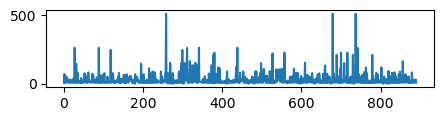

In [107]:
df.fare.plot(figsize=(5,1))  # линейный график по умолчанию

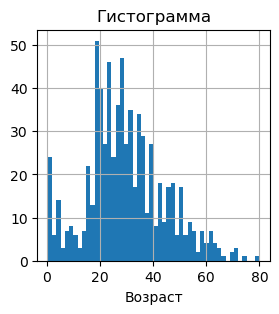

In [108]:
df['age'].hist(figsize=(3,3), bins=50)
plt.xlabel('Возраст')
plt.title('Гистограмма')
plt.show()

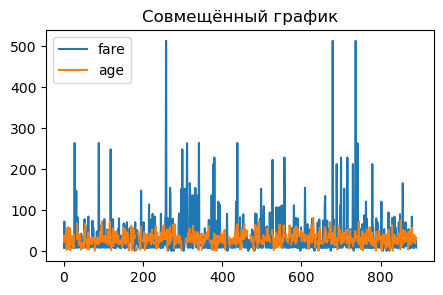

In [109]:
df[['fare', 'age']].plot(figsize=(5,3))
plt.title('Совмещённый график')
plt.show()

<Axes: >

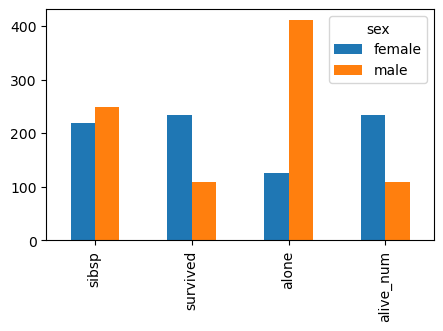

In [110]:
df['alive_num'] = df['alive']=='yes'
df.groupby('sex')[['sibsp', 'survived', 'alone', 'alive_num']].sum().T.plot.bar(figsize=(5,3))

---
<a id="seaborn"></a>
# 6. Seaborn

**Seaborn** — пакет для визуализации данных (на базе matplotlib).  
Содержит более сложные виды визуализаций, которые позволяет строить одной строкой

```python
import seaborn as sns
```

### Основные методы

| Метод | Описание |
|-------|----------|
| `sns.barplot(x, y)` | Столбчатая диаграмма |
| `sns.heatmap(x)` | Тепловая карта |
| `sns.scatterplot(x, y)` | Диаграмма рассеяния |
| `sns.FacetGrid(df)` | Связанные (фасетные) графики |
| `sns.boxplot(x)` | Диаграмма размаха |
| `sns.violinplot(x)` | Скрипичная диаграмма |
| `sns.pairplot(x)` | Парный график |
| `sns.histplot(x)` | Гистограмма |
| `sns.displot(x)` | Оценка распределения вероятностей |

**Когда использовать:** там, где нужны красивые и информативные графики — для презентации или глубокого анализа.

### Матрица корреляций

Матрица корреляций помогает оценить взаимосвязи между переменными.  
Вычисляется через `df.corr()` (pandas), отображается через тепловую карту Seaborn:
```python
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
```
На пересечении строки и столбца — значение коэффициента корреляции двух переменных.


Text(0.5, 1.0, 'Выживаемость по классу и полу')

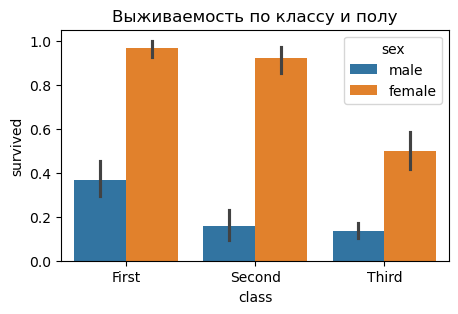

In [111]:
plt.figure(figsize=(5, 3)) 
sns.barplot(x="class", y="survived", hue="sex", data=df)
plt.title('Выживаемость по классу и полу')

Text(0.5, 1.0, 'Scatter: стоимость билета')

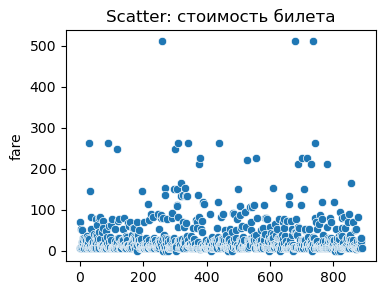

In [112]:
plt.figure(figsize=(4, 3)) 
sns.scatterplot(df['fare'])
plt.title('Scatter: стоимость билета')

Text(0.5, 1.0, 'Box plot: fare и age')

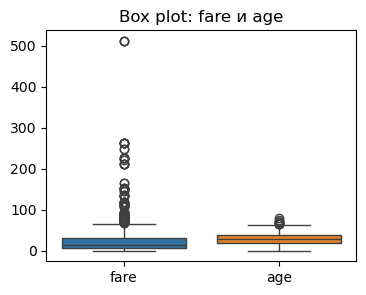

In [113]:
plt.figure(figsize=(4, 3)) 
sns.boxplot(df[['fare','age']])
plt.title('Box plot: fare и age')

Text(0.5, 1.0, 'Violin plot: возраст')

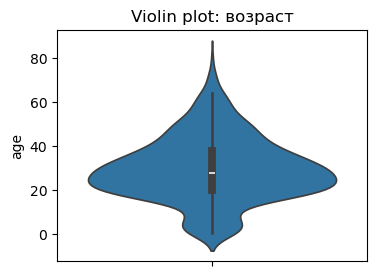

In [114]:
plt.figure(figsize=(4, 3)) 
sns.violinplot(df['age'])
plt.title('Violin plot: возраст')

Text(0.5, 1.0, 'Матрица корреляций')

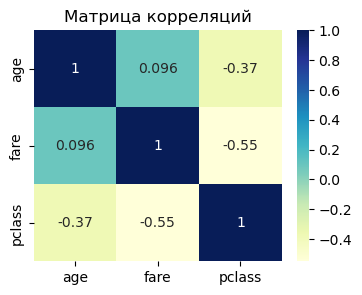

In [115]:
# Матрица корреляций
plt.figure(figsize=(4, 3)) 
sns.heatmap(df[['age','fare','pclass']].sort_values('age').corr(),
            cmap="YlGnBu",
            annot=True)
plt.title('Матрица корреляций')

---
<a id="итого"></a>
# 8. Памятка: виды анализа данных

| Вид анализа | Цель | Инструменты |
|-------------|------|-------------|
| **Описательный** (descriptive) | Количественное описание основных характеристик выборки | Pandas в большинстве случаев достаточно, в т.ч. для визуализации |
| **Разведочный** (exploratory, EDA) | Нахождение закономерностей, инсайтов, распределений, выбросов | Pandas для основных задач, SciPy/NumPy для вычислений, Plotly для интерактивности, Seaborn для красивых графиков |
| **Индуктивный** (inferential) | Оценка генеральной совокупности на основании выборки, причинно-следственные связи | Pandas или NumPy |
| **Прогностический** (predictive) | Предсказать поведение данных на основе прошлых значений | Библиотеки машинного обучения (следующий курс) |
| **Причинно-следственный** (causal) | Объяснение причин возникновения события | Библиотеки машинного обучения (следующий курс) |
